### Wczytanie danych

In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path("dataset")

train_df = pd.read_pickle(data_dir / "dataset_train.pkl")
val_df = pd.read_pickle(data_dir / "dataset_val.pkl")

train_df.info()

<class 'pandas.DataFrame'>
Index: 203 entries, 53 to 228
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID_nagrania  203 non-null    str    
 1   sygnał       203 non-null    object 
 2   źródło       203 non-null    str    
 3   label        203 non-null    int64  
 4   qSQI         203 non-null    float64
 5   cSQI         203 non-null    float64
 6   kurtosis     203 non-null    float64
dtypes: float64(3), int64(1), object(1), str(2)
memory usage: 12.7+ KB


# Sieć neuronowa (CNN)

Wybór **CNN** wynika z natury sygnału EKG – jest to sygnał czasowy o lokalnych wzorcach, takich jak załamki P, QRS i T, które powtarzają się regularnie. Sieci splotowe są w stanie automatycznie wydobywać te lokalne cechy bez potrzeby ręcznego ekstraktowania charakterystycznych punktów sygnału, co sprawia, że są idealne do klasyfikacji i detekcji anomalii w EKG.

## 1-D CNN jako klasyfikator

Na sygnale zastosowano **jednowymiarową sieć splotową (1D CNN)** składającą się z 4 warstw konwolucyjnych z funkcją aktywacji **ReLU**, które uczą się lokalnych cech czasowych sygnału. Po każdej warstwie konwolucyjnej zastosowano **max pooling**, aby zmniejszyć długość sekwencji, co redukuje liczbę parametrów i wprowadza translacyjną odporność sieci.  

Wybór **kernel_size** został dostosowany do charakterystycznej długości tych załamków. Większe jądra pozwalają wychwycić szersze wzorce, takie jak całe zespoły QRS, natomiast mniejsze (np. 3–7 próbek) skupiają się na krótkich, subtelnych cechach sygnału. Dzięki progresywnemu zmniejszaniu rozmiaru jądra w kolejnych warstwach sieć uczy się hierarchicznej reprezentacji – od lokalnych, krótkich zależności po bardziej globalne wzorce czasowe.

Dodatkowo wprowadzono **batch normalization** w celu stabilizacji uczenia i przyspieszenia konwergencji oraz **dropout**, aby ograniczyć przetrenowanie (overfitting), szczególnie istotne przy niewielkiej liczbie próbek.  

Na końcu sieć wykonuje **global average pooling**, który agreguje informacje wzdłuż całego sygnału, a następnie spłaszcza dane (**flatten**) przed warstwą **w pełni połączoną (fully connected)**, która klasyfikuje sygnał do odpowiedniej liczby klas.  

Takie podejście pozwala sieci automatycznie uczyć się reprezentacji sygnału EKG na różnych skalach czasowych – od bardzo krótkich, lokalnych cech (np. kształt pojedynczego załamka) po dłuższe wzorce obejmujące całe cykle serca. Dzięki odpowiedniemu doborowi **kernel_size** i liczby warstw sieć może wychwycić subtelne anomalie i różnice w rytmach, co jest trudne do osiągnięcia przy tradycyjnych metodach ekstrakcji cech.

Epoch 1/50 | Train acc: 0.6914 | Test acc: 0.6341
Epoch 2/50 | Train acc: 0.8395 | Test acc: 0.6098
Epoch 3/50 | Train acc: 0.9136 | Test acc: 0.6341
Epoch 4/50 | Train acc: 0.9383 | Test acc: 0.6098
Epoch 5/50 | Train acc: 0.8457 | Test acc: 0.8780
Epoch 6/50 | Train acc: 0.9383 | Test acc: 0.7805
Epoch 7/50 | Train acc: 0.9259 | Test acc: 0.7561
Epoch 8/50 | Train acc: 0.9321 | Test acc: 0.7561
Epoch 9/50 | Train acc: 0.9568 | Test acc: 0.7561
Early stopping at epoch 10. Best val acc: 0.8780

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.95      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



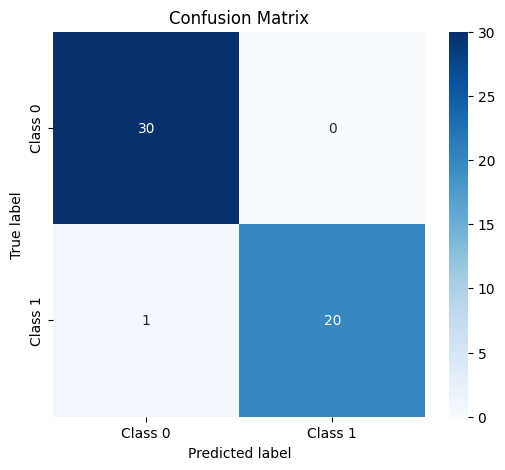

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)

def prepare_signals(df):
    signals = []
    for idx, s in enumerate(df['sygnał']):
        arr = np.array(s, dtype=np.float32).flatten()
        target_len = 2500
        if arr.size == 0:
            print(f"Warning: Empty signal at index {idx}, skipping.")
            continue
        if len(arr) < target_len:
            arr = np.pad(arr, (0, target_len - len(arr)))
        else:
            arr = arr[:target_len]
        if arr.shape != (target_len,):
            print(f"Warning: Signal at index {idx} has shape {arr.shape}, expected ({target_len},)")
            continue
        signals.append(arr)
    if len(signals) == 0:
        raise ValueError("No valid signals found in the DataFrame.")
    signals = np.stack(signals)
    signals = signals[:, np.newaxis, :]
    return torch.tensor(signals)

def prepare_labels(df):
    return torch.tensor(df['label'].values, dtype=torch.long)

def get_data(train_df, val_df):
    X_train = prepare_signals(train_df)
    X_val = prepare_signals(val_df)
    y_train = prepare_labels(train_df)
    y_val = prepare_labels(val_df)
    return X_train, X_val, y_train, y_val

class CNN(nn.Module):
    def __init__(self, num_classes, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=15, padding=7)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=3)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.drop2 = nn.Dropout(dropout)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)
        self.drop3 = nn.Dropout(dropout)
        
        self.conv4 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm1d(128)
        self.pool4 = nn.MaxPool1d(2)
        self.drop4 = nn.Dropout(dropout)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.drop2(self.pool2(F.relu(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x)))))
        x = self.drop4(self.pool4(F.relu(self.bn4(self.conv4(x)))))
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

def train_cnn(
        X_train, y_train, num_classes=2, num_epochs=25, batch_size=32, lr=1e-3,
        test_size=0.2, device=None, print_every=5, patience=5
    ):
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_train, X_test, y_train, y_test = train_test_split(
        X_train, y_train, test_size=test_size, stratify=y_train, random_state=42
    )

    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    
    model = CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    trigger_times = 0
    best_model_state = None
    
    for epoch in range(1, num_epochs+1):
        model.train()
        correct, total = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
        train_acc = correct / total
        
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == yb).sum().item()
                val_total += yb.size(0)
        val_acc = val_correct / val_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping at epoch {epoch}. Best val acc: {best_val_acc:.4f}")
                model.load_state_dict(best_model_state)
                break
        
        if epoch % print_every == 0 or epoch == num_epochs:
            print(f"Epoch {epoch}/{num_epochs} | Train acc: {train_acc:.4f} | Test acc: {val_acc:.4f}")
    
    return model, device

def evaluate_cnn(model, X_eval, y_eval, device, class_names=None):
    model.eval()
    ds = TensorDataset(X_eval, y_eval)
    loader = DataLoader(ds, batch_size=32)
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(yb.numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

X_train = prepare_signals(train_df)
y_train = prepare_labels(train_df)

model, device = train_cnn(X_train, y_train, print_every=1, num_epochs=50)

X_val = prepare_signals(val_df)
y_val = prepare_labels(val_df)

evaluate_cnn(model, X_val, y_val, device)

## CNN jako ekstraktor cech

Do ekstrakcji cech z sygnałów wykorzystano wcześniej wytrenowaną **jednowymiarową sieć splotową (1D CNN)**. Sieć została użyta jako **feature extractor**, gdzie wyjście z warstw konwolucyjnych i poolingowych jest spłaszczane i traktowane jako reprezentacja cech sygnału.  

Następnie uzyskane cechy zostały połączone z cechami jakości i wykorzystane jako wejście do poniższych klasyfikatorów.

In [3]:
from sklearn.preprocessing import StandardScaler

class CNN_FeatureExtractor(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.features = nn.Sequential(
            trained_model.conv1,
            trained_model.bn1,
            nn.ReLU(),
            trained_model.pool1,
            
            trained_model.conv2,
            trained_model.bn2,
            nn.ReLU(),
            trained_model.pool2,
            trained_model.drop2,
            
            trained_model.conv3,
            trained_model.bn3,
            nn.ReLU(),
            trained_model.pool3,
            trained_model.drop3,
            
            trained_model.conv4,
            trained_model.bn4,
            nn.ReLU(),
            trained_model.pool4,
            trained_model.drop4,
            
            trained_model.global_pool,
            nn.Flatten()
        )

    def forward(self, x):
        return self.features(x)
    
def extract_features(model, X, batch_size=32, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    features = []
    loader = DataLoader(TensorDataset(X), batch_size=batch_size)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            feats = model(xb)
            features.append(feats.cpu().numpy())
    return np.vstack(features)

def get_quality_features(df):
    quality_cols = ['qSQI', 'cSQI', 'kurtosis']
    return df[quality_cols].values.astype(np.float32)

def evaluate_classifier(clf, X_features, y_true, class_names=None):
    y_pred = clf.predict(X_features)
    
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

scaler = StandardScaler()

feature_extractor = CNN_FeatureExtractor(model).to(device).eval()
features_train = extract_features(feature_extractor, X_train, device=device)
quality_features_train = get_quality_features(train_df)
X_train_features = scaler.fit_transform(np.hstack([features_train, quality_features_train]))

features_val = extract_features(feature_extractor, X_val, device=device)
quality_features_val = get_quality_features(val_df)
X_val_features = scaler.transform(np.hstack([features_val, quality_features_val]))

### KNN

Best params:  {'knn__n_neighbors': 3}
Best CV score: 0.9704878048780488

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.95      1.00      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



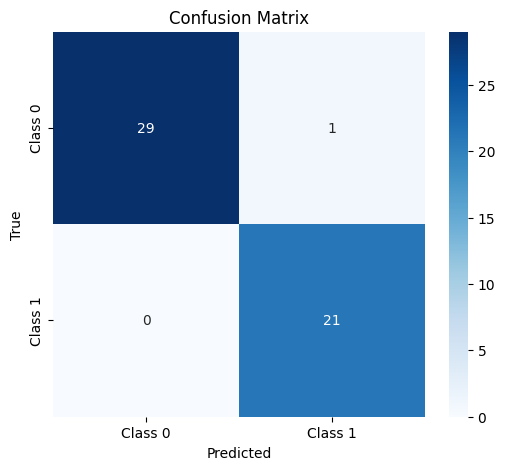

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('knn', KNeighborsClassifier(weights='distance'))
])

param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)

### SVM

Best params:  {'svm__C': 0.1, 'svm__gamma': 'scale'}
Best CV score: 0.9704878048780488

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.95      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



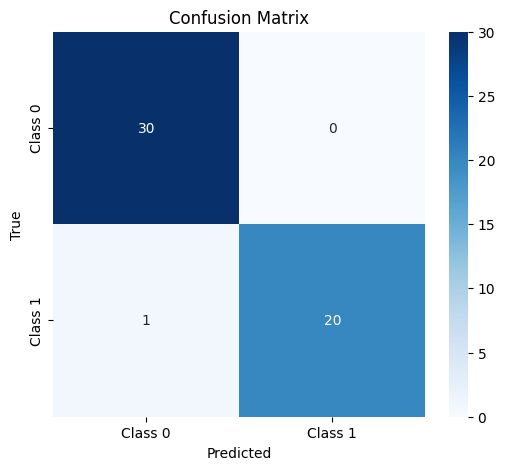

In [5]:
from sklearn.svm import SVC

pipeline = Pipeline([
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)

### Random Forest

Best params:  {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
Best CV score: 0.9704878048780488

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        21

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



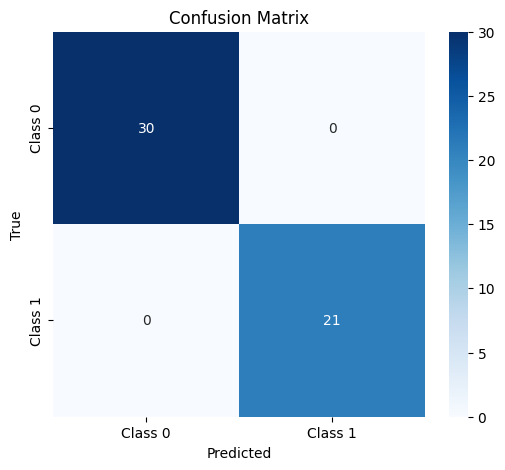

In [6]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)

### MLP (Multi-Layer Perceptron)

Best params:  {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (100, 50)}
Best CV score: 0.9803658536585365

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.95      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



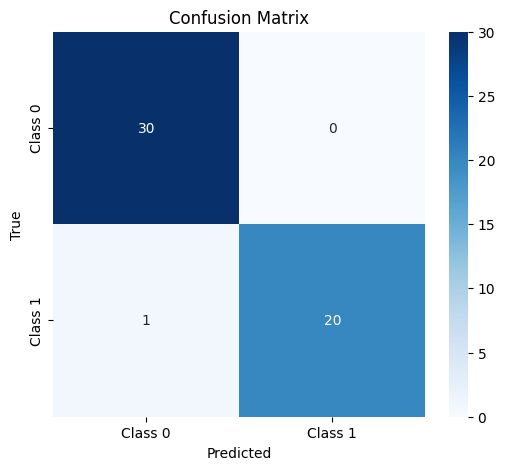

In [7]:
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)